In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('../../src')))

from pyoma2.algorithms import pLSCF,FSDD,SSIcov
from pyoma2.setup import SingleSetup

In [2]:
data = pd.read_csv("Prueba.txt", sep='\t')
data = data.to_numpy()

In [3]:
#n_accel = 7 # Number of sensors
#n_channel = 2 # Number of channels/sensor

In [4]:
#fig, axs = plt.subplots(n_accel, n_channel, figsize=(10, 10))
#z = 0
#for i in range(n_accel):
#  for j in range(n_channel):
#    ax = axs[i, j]
#    ax.plot(data[:, z])
#    z += 1
#
#fig.tight_layout()  # Ajusta el espaciado
#plt.subplots_adjust(hspace=0.3, wspace=0.3)  # Ajusta el espaciado entre subplots
#
#plt.show()

In [5]:
frame_4P = SingleSetup(data, fs=250)

frame_4P.def_geo1_by_file("Geo1.xlsx")
frame_4P.def_geo2_by_file("Geo2.xlsx")

In [6]:
frame_4P.geo1.bg_nodes

array([[0.  , 0.  , 0.  ],
       [0.5 , 0.  , 0.  ],
       [0.5 , 0.5 , 0.  ],
       [0.  , 0.5 , 0.  ],
       [0.  , 0.  , 0.52],
       [0.5 , 0.  , 0.52],
       [0.5 , 0.5 , 0.52],
       [0.  , 0.5 , 0.52],
       [0.  , 0.  , 1.04],
       [0.5 , 0.  , 1.04],
       [0.5 , 0.5 , 1.04],
       [0.  , 0.5 , 1.04],
       [0.  , 0.  , 1.56],
       [0.5 , 0.  , 1.56],
       [0.5 , 0.5 , 1.56],
       [0.  , 0.5 , 1.56],
       [0.  , 0.  , 2.08],
       [0.5 , 0.  , 2.08],
       [0.5 , 0.5 , 2.08],
       [0.  , 0.5 , 2.08]])

In [7]:
#_, _ = frame_4P.plot_geo1(scaleF=0.1)
dsds = frame_4P.plot_geo2(scaleF=0.1)

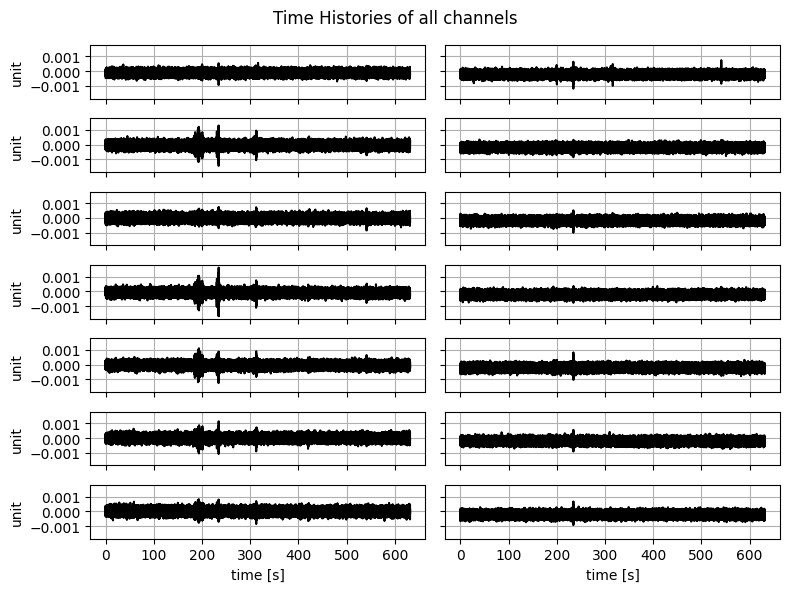

In [8]:
_, _ = frame_4P.plot_data(nc=2)

In [9]:
frame_4P.filter_data(Wn=(0.1, 25), order=8, btype="bandpass")
frame_4P.decimate_data(q=5)
#_, _ = frame_4P.plot_ch_info(ch_idx=[0])

In [10]:
# Initialise the algorithms
fsdd = FSDD(name="FSDD", nxseg=1024, method_SD="cor")
ssicov = SSIcov(name="SSIcov", br=30, ordmax=30, calc_unc=True)
plscf = pLSCF(name="polymax",ordmax=30)

# Overwrite/update run parameters for an algorithm
fsdd.run_params = FSDD.RunParamCls(nxseg=1024, method_SD="per", pov=0.5)

# Add algorithms to the single setup class
frame_4P.add_algorithms(ssicov, fsdd, plscf)

# Run all or run by name
frame_4P.run_by_name("SSIcov")
frame_4P.run_by_name("FSDD")
frame_4P.run_by_name("polymax")
# frame_4P.run_all()

# save dict of results
ssi_res = ssicov.result.model_dump()
fsdd_res = dict(fsdd.result)

2025-04-29 15:37:36,412 - pyoma2.setup.base - INFO - Running SSIcov... (base:123)
2025-04-29 15:37:36,414 - pyoma2.functions.ssi - INFO - Assembling Hankel matrix method: cov... (ssi:82)
2025-04-29 15:37:36,614 - pyoma2.functions.ssi - INFO - ... calculating cov(H)... (ssi:93)
2025-04-29 15:37:37,323 - pyoma2.functions.ssi - INFO - SSI for increasing model order... (ssi:321)
100%|██████████| 31/31 [00:00<00:00, 15547.46it/s]
2025-04-29 15:37:37,413 - pyoma2.functions.ssi - INFO - ... propagating uncertainty... (ssi:448)
100%|██████████| 30/30 [00:25<00:00,  1.18it/s]
2025-04-29 15:38:02,927 - pyoma2.functions.ssi - INFO - Calculating modal parameters for increasing model order... (ssi:486)
100%|██████████| 31/31 [00:00<00:00, 112.39it/s]
2025-04-29 15:38:03,319 - pyoma2.setup.base - INFO - Running FSDD... (base:123)
2025-04-29 15:38:03,483 - pyoma2.setup.base - INFO - Running polymax... (base:123)
100%|██████████| 30/30 [00:08<00:00,  3.42it/s]


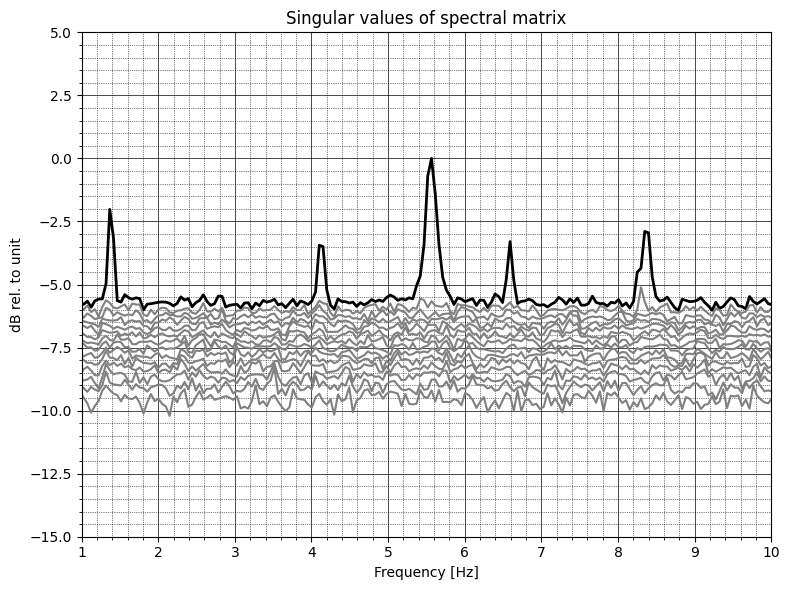

In [11]:
# plot Singular values of PSD
fig1, ax = fsdd.plot_CMIF()
ax.set_xlim(1, 10)
ax.set_ylim(-15, 5)
ax.minorticks_on()
ax.grid(which='major', linestyle='-', linewidth='0.5', color='black')
ax.grid(which='minor', linestyle=':', linewidth='0.5', color='black')

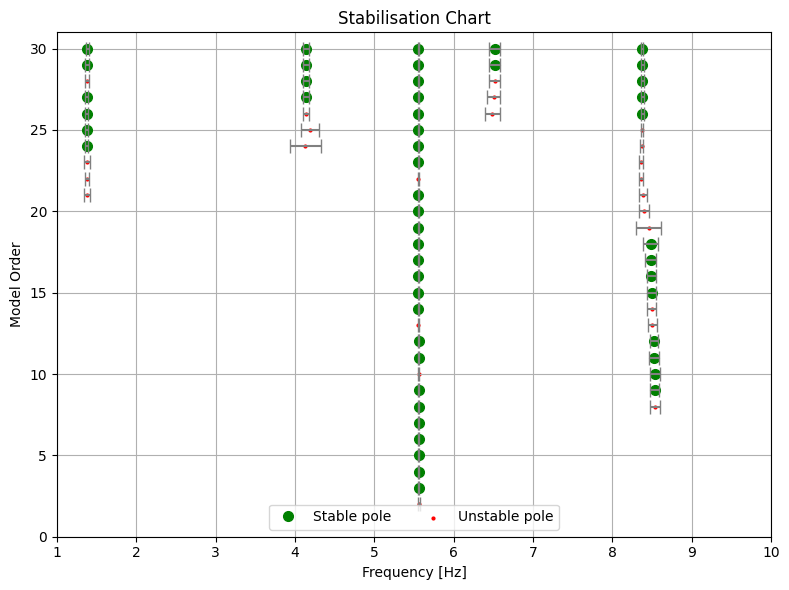

In [12]:
# plot Stabilisation chart for SSI
_, _ = ssicov.plot_stab(freqlim=(1,10), hide_poles=False)

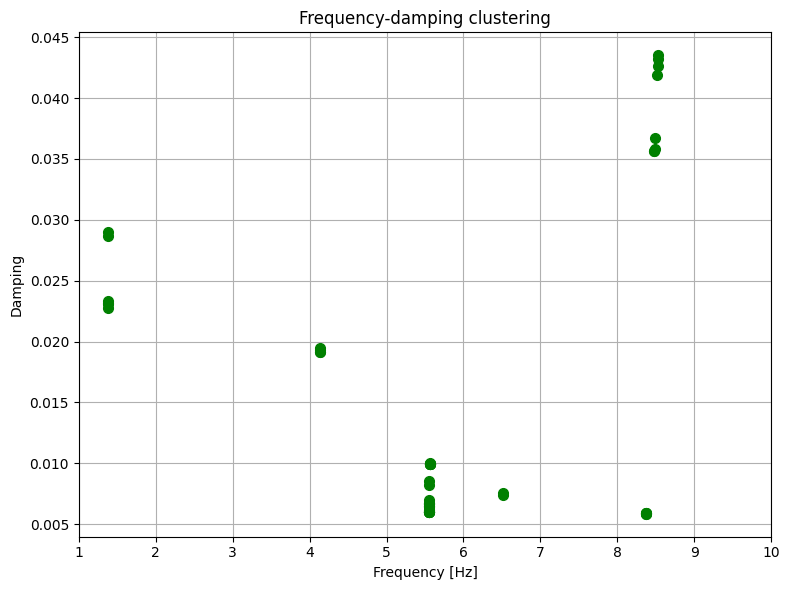

In [13]:
# plot frequecy-damping clusters for SSI
_, _ = ssicov.plot_freqvsdamp(freqlim=(1,10))

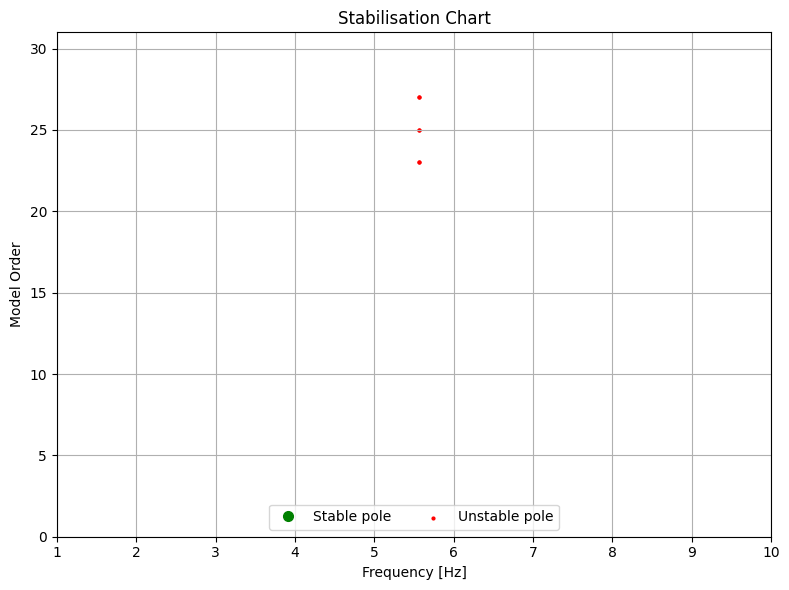

In [14]:
# plot Stabilisation chart for pLSCF
_, _ = plscf.plot_stab(freqlim=(1,10), hide_poles=False)

In [19]:
# Select modes to extract from plots
#frame_4P.mpe_from_plot("FSDD", freqlim=(0.5,15), MAClim=0.95)

# or directly
frame_4P.mpe("SSIcov", sel_freq=[1.4, 4.1, 5.6, 6.6, 8.4], order_in=20)

# update dict of results
fsdd_res = dict(ssicov.result)

# or directly
frame_4P.mpe("FSDD", sel_freq=[1.4, 4.1, 5.6, 6.6, 8.4], MAClim=0.95)

# update dict of results
fsdd_res = dict(fsdd.result)

2025-04-29 15:43:03,560 - pyoma2.setup.base - INFO - Getting mpe modal parameters from SSIcov (base:149)
2025-04-29 15:43:03,561 - pyoma2.functions.ssi - INFO - Extracting SSI modal parameters (ssi:889)
100%|██████████| 5/5 [00:00<00:00, 5008.72it/s]
2025-04-29 15:43:03,566 - pyoma2.setup.base - INFO - Getting mpe modal parameters from FSDD (base:149)
2025-04-29 15:43:03,617 - pyoma2.functions.fdd - INFO - Extracting FDD modal parameters (fdd:284)
100%|██████████| 5/5 [00:00<00:00, 5013.51it/s]
2025-04-29 15:43:03,621 - pyoma2.functions.fdd - INFO - Extracting EFDD modal parameters (fdd:492)
100%|██████████| 5/5 [00:00<00:00, 20.84it/s]


In [20]:
print(ssicov.result.Fn)

[5.55438163 5.55438163 5.55438163 5.55438163 8.39522793]


In [21]:
print(fsdd.result.Fn)

[  1.37286383   4.11844326   5.54258236 -42.36111177   8.35289519]


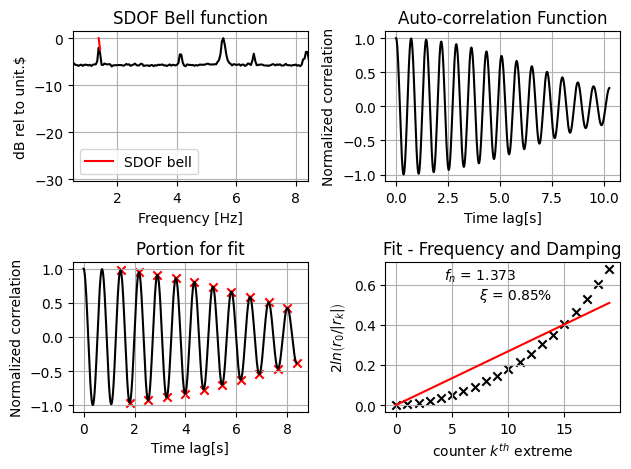

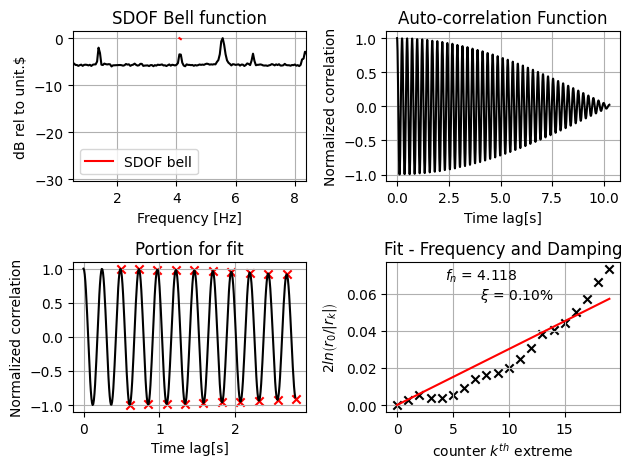

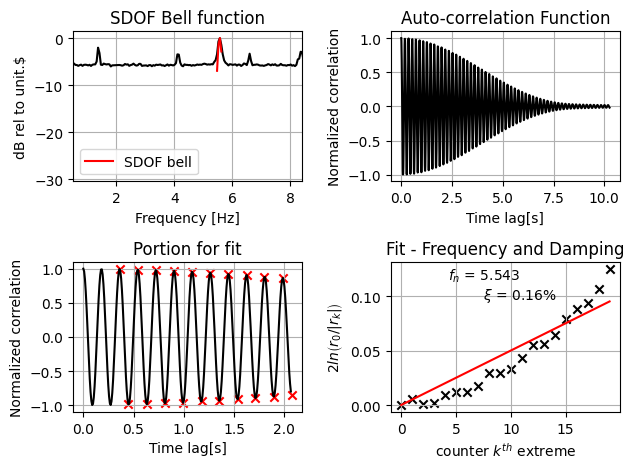

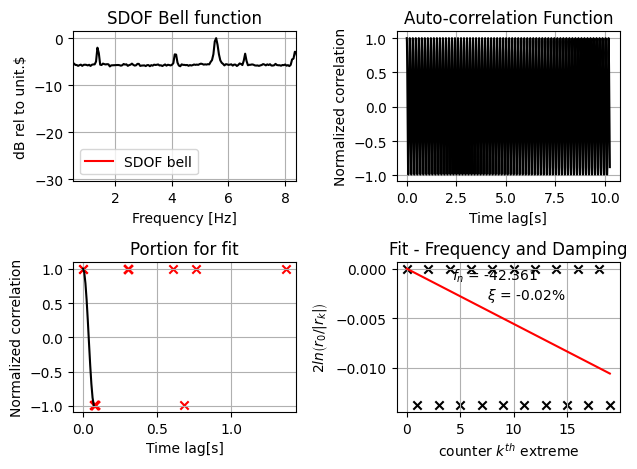

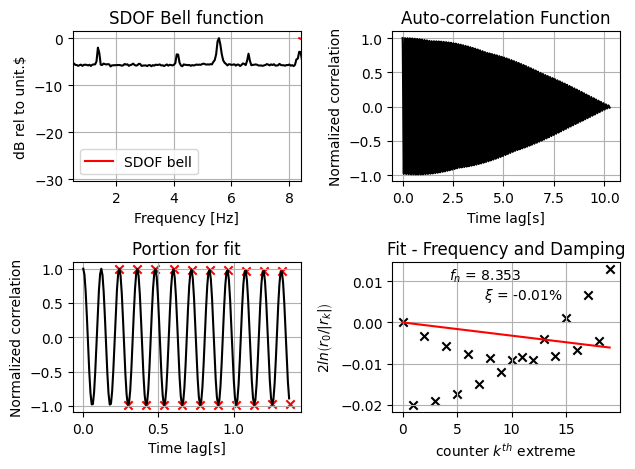

In [22]:
# plot additional info (goodness of fit) for EFDD or FSDD
_, _ = frame_4P[fsdd.name].plot_EFDDfit(freqlim=(0.5,8.4))

In [26]:
# Mode shape plots
# Plot mode 1 (geometry 1)
frame_4P.plot_mode_geo2(algo_res=fsdd.result, mode_nr=1, view="3D", scaleF=0.5)
frame_4P.plot_mode_geo2(algo_res=fsdd.result, mode_nr=2, view="3D", scaleF=0.5)
frame_4P.plot_mode_geo2(algo_res=fsdd.result, mode_nr=3, view="3D", scaleF=0.5)
frame_4P.plot_mode_geo2(algo_res=fsdd.result, mode_nr=4, view="3D", scaleF=0.5)
frame_4P.plot_mode_geo2(algo_res=fsdd.result, mode_nr=5, view="3D", scaleF=0.5)

# Show the plot
plt.show()

In [24]:
# Animate mode 1 (geometry 2)
frame_4P.geo2
_ = frame_4P.anim_mode_geo2(algo_res=ssicov.result, mode_nr=1, scaleF=3)

In [25]:
import os
import sys
import pathlib
# Add the directory we executed the script from to path:
sys.path.insert(0, os.path.realpath('__file__'))

from pyoma2.functions.gen import save_to_file, load_from_file

# Save setup
save_to_file(frame_4P, pathlib.Path(r"./test.pkl"))

